# **1- import libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import seaborn as sns

In [2]:
df = pd.read_csv('data.csv')
df

,price,brand,model,year,condition,kilo_meter,color,power_trans,fuel_type,location,price_bin
0,2000000.0,Cadillac,Escalade,2018,Used,"185,000 KM",Black,Automatic,Diesel,Tagamo3 - New Cairo,0.7
1,2000000.0,Seat,Tarraco,2024,Used,"45,000 KM",Black,Automatic,Gas,Cairo,0.7
2,1050000.0,Toyota,Corolla,2020,Used,"44,000 KM",White,Automatic,Gas,Nasr city,0.3
3,1120000.0,Skoda,Octavia,2020,Used,"125,000 KM",Gray,Automatic,Gas,Nasr city,0.4
4,1020000.0,Hyundai,Elantra,2027,New,0 KM,Dark blue,Automatic,Gas,Mohandessin,0.3
...,...,...,...,...,...,...,...,...,...,...,...
20456,1385000.0,Toyota,Corolla,2025,Used,"10,000",Gray,Automatic,Benzine,Giza,0.5
20457,620000.0,Kia,Rio,2017,Used,"135,000",Brown,Automatic,Benzine,Nasr City,0.2
20458,1795000.0,Deepal,S07,2024,New,0,Gray,Automatic,Electric,Cairo,0.6
20459,770000.0,Chrysler,Town and Country,2010,Used,"300,000",Gray,Automatic,Benzine,Cairo,0.2


In [3]:
df.shape

(20461, 11)

In [4]:
df.head()

,price,brand,model,year,condition,kilo_meter,color,power_trans,fuel_type,location,price_bin
0,2000000.0,Cadillac,Escalade,2018,Used,"185,000 KM",Black,Automatic,Diesel,Tagamo3 - New Cairo,0.7
1,2000000.0,Seat,Tarraco,2024,Used,"45,000 KM",Black,Automatic,Gas,Cairo,0.7
2,1050000.0,Toyota,Corolla,2020,Used,"44,000 KM",White,Automatic,Gas,Nasr city,0.3
3,1120000.0,Skoda,Octavia,2020,Used,"125,000 KM",Gray,Automatic,Gas,Nasr city,0.4
4,1020000.0,Hyundai,Elantra,2027,New,0 KM,Dark blue,Automatic,Gas,Mohandessin,0.3


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20461 entries, 0 to 20460
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   price        20461 non-null  float64
 1   brand        20461 non-null  str    
 2   model        20461 non-null  str    
 3   year         20461 non-null  str    
 4   condition    20461 non-null  str    
 5   kilo_meter   20461 non-null  str    
 6   color        20461 non-null  str    
 7   power_trans  20461 non-null  str    
 8   fuel_type    20461 non-null  str    
 9   location     20461 non-null  str    
 10  price_bin    20461 non-null  float64
dtypes: float64(2), str(9)
memory usage: 2.8 MB


--------> All columns are string data type

# **2- check missing & duplications**

In [6]:
df.isnull().sum()

price          0
brand          0
model          0
year           0
condition      0
kilo_meter     0
color          0
power_trans    0
fuel_type      0
location       0
price_bin      0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

### --------> No Missing Value and find **1014** Duplicated rows

### --------> Delete duplicated data


In [8]:
df.drop_duplicates(inplace = True)

In [9]:
df.duplicated().sum()

np.int64(0)

# Check outliers

In [10]:
# Convert price column to numeric and Chick outliers
df['price'] = (
    df['price']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('EGP', '', regex=False)
    .str.strip()
)

df['price'] = pd.to_numeric(df['price'], errors='coerce')

In [11]:
fig = px.box(
    df,
    x='price',
    title='Car Price Distribution After Removing Outliers'
)

fig.show()

# Handel Ouliers

In [12]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [13]:
df = df[
    (df['price'] >= lower) &
    (df['price'] <= upper)
]

In [14]:
df['price_bin'] = pd.cut(
    df['price'],
    bins=10,
    labels=False
)
df['price_bin'] = df['price_bin'] / 10
df['price_bin'].value_counts()

price_bin
0.1    4309
0.2    3532
0.3    3011
0.0    2952
0.4    1849
0.5    1539
0.6     884
0.7     801
0.8     612
0.9     537
Name: count, dtype: int64

In [15]:
df['price_bin'].value_counts().sort_index()

price_bin
0.0    2952
0.1    4309
0.2    3532
0.3    3011
0.4    1849
0.5    1539
0.6     884
0.7     801
0.8     612
0.9     537
Name: count, dtype: int64

In [16]:
pd.cut(
    df['price'],
    bins=10
).value_counts().sort_index()

price
(-1424.0, 243400.0]       2952
(243400.0, 485800.0]      4309
(485800.0, 728200.0]      3532
(728200.0, 970600.0]      3011
(970600.0, 1213000.0]     1849
(1213000.0, 1455400.0]    1539
(1455400.0, 1697800.0]     884
(1697800.0, 1940200.0]     801
(1940200.0, 2182600.0]     612
(2182600.0, 2425000.0]     537
Name: count, dtype: int64

In [17]:
for b in sorted(df['price_bin'].dropna().unique()):
    print(f"\n===== BIN {b} =====")
    print(df[df['price_bin'] == b][
        ['price', 'brand', 'model', 'year', 'condition']
    ].head(10))


===== BIN 0.0 =====
        price       brand            model  year condition
12   150000.0        Fiat           Shahin  2006      Used
33   150000.0        Seat            Ibiza  1998      Used
53   160000.0     Hyundai            Excel  1993      Used
54    60000.0      Citro雗               Ax  1996      Used
73   230000.0      Daewoo          Leganza  2002      Used
114  225000.0  Mitsubishi  Lancer Crystala  1998      Used
116  170000.0      Toyota         Cressida  1983      Used
146  200000.0     Renault             Clio  2003      Used
167   90000.0        Fiat           Tempra  1998      Used
168  145000.0     Hyundai            Excel  1997      Used

===== BIN 0.1 =====
       price      brand     model  year condition
18  350000.0        Byd        F3  2015      Used
34  350000.0     Suzuki      Alto  2019      Used
36  430000.0        Byd        F3  2019      Used
43  250000.0   Daihatsu  Gran max  2011      Used
45  280000.0     Daewoo  Nubira 2  1999      Used
74  28000

In [43]:
df["kilo_meter"] = (
    df["kilo_meter"]
    .str.replace(r"[A-Za-z]", "", regex=True)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["kilo_meter"] = pd.to_numeric(
    df["kilo_meter"],
    errors="coerce"
).astype("Int64")

## Visualizaion In file **cars_dash.py**

Text(0.5, 0, 'Price (EGP)')

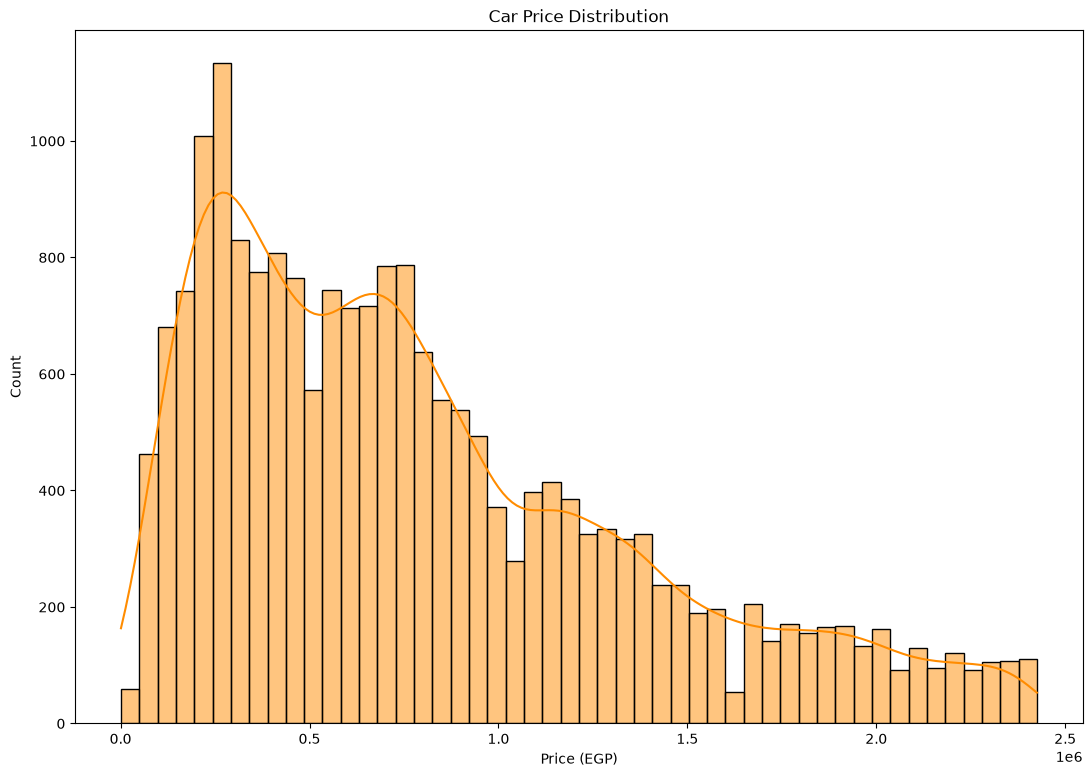

In [34]:
fig, axes = plt.subplots(figsize=(13, 9))
sns.histplot(df['price'], bins=50, kde=True, color='darkorange')
axes.set_title('Car Price Distribution')
axes.set_xlabel('Price (EGP)')

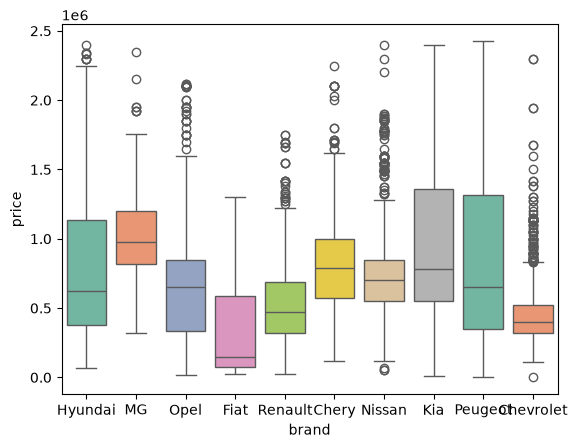

In [36]:
top_brands = df['brand'].value_counts().head(10).index
sns.boxplot(data=df[df['brand'].isin(top_brands)], x='brand', y='price', hue='brand',
            palette='Set2', legend=False)
axes.set_title('Price by Brand (Top 10 by Volume)')
axes.tick_params(axis='x', rotation=45)

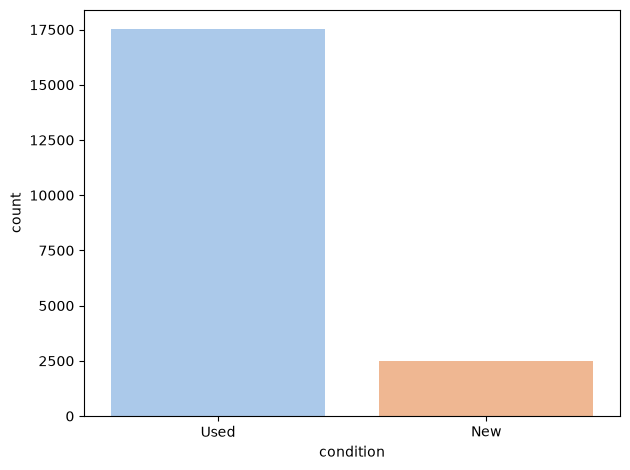

In [38]:
sns.countplot(data=df, x='condition', hue='condition', palette='pastel', legend=False)
axes.set_title('Condition Distribution')
plt.tight_layout()
plt.show()

In [48]:
df['year'].value_counts()

year
2026         1528
2021         1247
2027         1184
2022         1121
2019          892
             ... 
1969            2
1965            1
Automatic       1
1951            1
1964            1
Name: count, Length: 66, dtype: int64

In [50]:
df = df[df["year"] != "Automatic"].reset_index(drop=True)

Text(0.5, 1.0, 'Numeric Feature Correlation Heatmap')

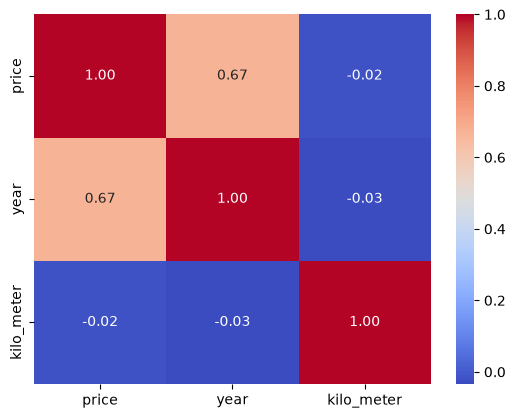

In [51]:
numeric_cols_car = ['price', 'year', 'kilo_meter']
sns.heatmap(df[numeric_cols_car].corr(), annot=True, fmt='.2f', cmap='coolwarm')
axes.set_title('Numeric Feature Correlation Heatmap')

In [18]:
# df.to_csv('data.csv', index=False, encoding='utf-8-sig')

In [19]:
df.head()

,price,brand,model,year,condition,kilo_meter,color,power_trans,fuel_type,location,price_bin
0,2000000.0,Cadillac,Escalade,2018,Used,"185,000 KM",Black,Automatic,Diesel,Tagamo3 - New Cairo,0.8
1,2000000.0,Seat,Tarraco,2024,Used,"45,000 KM",Black,Automatic,Gas,Cairo,0.8
2,1050000.0,Toyota,Corolla,2020,Used,"44,000 KM",White,Automatic,Gas,Nasr city,0.4
3,1120000.0,Skoda,Octavia,2020,Used,"125,000 KM",Gray,Automatic,Gas,Nasr city,0.4
4,1020000.0,Hyundai,Elantra,2027,New,0 KM,Dark blue,Automatic,Gas,Mohandessin,0.4


In [20]:
X = df.drop(['price', 'price_bin'], axis=1)
y = df['price']

In [21]:
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns

C:\Users\Dell\AppData\Local\Temp\ipykernel_8336\3607657429.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
global_mean = y_train.mean()

encoding_maps = {}

for col in categorical_cols:

    temp = pd.DataFrame({
        col: X_train[col],
        "price": y_train
    })

    stats = temp.groupby(col)["price"].agg(["mean", "count"])

    alpha = 10

    stats["encoded"] = (
        stats["mean"] * stats["count"] +
        global_mean * alpha
    ) / (stats["count"] + alpha)

    encoding_maps[col] = stats["encoded"].to_dict()

In [24]:
X_train_encoded = X_train.copy()

for col in categorical_cols:
    X_train_encoded[col] = (
        X_train_encoded[col]
        .map(encoding_maps[col])
        .fillna(global_mean)
    )

X_train_encoded = X_train_encoded.astype(float)

In [25]:
X_test_encoded = X_test.copy()

for col in categorical_cols:
    X_test_encoded[col] = (
        X_test_encoded[col]
        .map(encoding_maps[col])
        .fillna(global_mean)
    )

X_test_encoded = X_test_encoded.astype(float)

In [26]:
print(X_train_encoded.shape)
print(X_test_encoded.shape)

(16020, 9)
(4006, 9)


In [27]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

model.fit(
    X_train_encoded,
    y_train
)

print("Model trained successfully!")

Model trained successfully!


In [28]:
y_pred = model.predict(X_test_encoded)

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

MAE: 87,094.43
RMSE: 148,895.77
R² Score: 0.9310


In [30]:
model.save_model("car_price_model.json")

In [31]:
import pickle

artifacts = {
    "encoding_maps": encoding_maps,
    "global_mean": global_mean,
    "categorical_cols": list(categorical_cols)
}

with open("car_price_encoder.pkl", "wb") as file:
    pickle.dump(artifacts, file)

print("Files saved successfully!")

Files saved successfully!


In [32]:
car = {
    "brand": "Toyota",
    "model": "Corolla",
    "year": 2020,
    "condition": "Used",
    "kilo_meter": 80000,
    "color": "White",
    "power_trans": "Automatic",
    "fuel_type": "Petrol",
    "location": "Cairo"
}

new_car = pd.DataFrame([car])

In [33]:
for col in categorical_cols:
    new_car[col] = (
        new_car[col]
        .map(encoding_maps[col])
        .fillna(global_mean)
    )

new_car = new_car.astype(float)